# 05 — Out-of-Domain Evaluation & Error Analysis

This notebook covers the final evaluation stage of the Satellite Land-Use Classifier. We will:
1. Load the UC Merced dataset mapped to EuroSAT categories as an out-of-domain holdout set.
2. Load our fine-tuned Block Split ResNet-18 model.
3. Run inference on UC Merced and calculate performance metrics (Accuracy, Precision, Recall, F1).
4. Conduct detailed error analysis on the top-5 most confident misclassifications and present hypotheses explaining the failures.

In [1]:
import sys, os
# Resolve project root dynamically
if os.path.exists('src'):
    ROOT_DIR = '.'
else:
    ROOT_DIR = '..'
sys.path.append(ROOT_DIR)

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns

from src.dataset import UCMercedMappedDataset, EUROSAT_CLASSES
from src.model import TransferLearningModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_ROOT = os.path.join(ROOT_DIR, "data", "raw")
MODELS_DIR = os.path.join(ROOT_DIR, "models")
REPORTS_DIR = os.path.join(ROOT_DIR, "reports")
os.makedirs(REPORTS_DIR, exist_ok=True)

Using device: cpu


## 1. Load UC Merced Holdout Dataset and Trained Model

In [2]:
# Setup transforms matching ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Load UC Merced mapped dataset
ucm_root = os.path.join(DATA_ROOT, "uc_merced")
ucm_dataset = UCMercedMappedDataset(root_dir=ucm_root, transform=eval_transform)
ucm_loader = DataLoader(ucm_dataset, batch_size=32, shuffle=False, num_workers=0)
print(f"Loaded UC Merced dataset size: {len(ucm_dataset)} samples")

# Load Block-split ResNet-18 model
model = TransferLearningModel(num_classes=10, backbone_name="resnet18").to(device)
model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "resnet18_block_final.pt"), map_location=device))
model.eval()
print("Model loaded successfully.")

Loaded UC Merced dataset size: 1100 samples


Model loaded successfully.


## 2. Evaluate performance on UC Merced

In [3]:
all_probs = []
all_preds = []
all_labels = []
all_paths = []

with torch.no_grad():
    for i, (images, labels) in enumerate(ucm_loader):
        images = images.to(device)
        outputs = model(images)
        probs = outputs.softmax(dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
        
        # Store absolute paths for error visualization
        start_idx = i * 32
        end_idx = min(start_idx + 32, len(ucm_dataset))
        for idx in range(start_idx, end_idx):
            all_paths.append(ucm_dataset.samples[idx][0])

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro')
print(f"Out-of-Domain (UC Merced) Accuracy: {accuracy:.4f}")
print(f"Out-of-Domain (UC Merced) Macro-F1: {macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=EUROSAT_CLASSES))

Out-of-Domain (UC Merced) Accuracy: 0.2400
Out-of-Domain (UC Merced) Macro-F1: 0.1756

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.22      0.51      0.31       100
              Forest       0.55      0.41      0.47       100
HerbaceousVegetation       0.00      0.00      0.00         0
             Highway       0.33      0.04      0.08       200
          Industrial       0.30      0.37      0.33       200
             Pasture       0.00      0.00      0.00         0
       PermanentCrop       0.00      0.00      0.00         0
         Residential       0.28      0.07      0.12       300
               River       0.70      0.34      0.45       200
             SeaLake       0.00      0.00      0.00         0

            accuracy                           0.24      1100
           macro avg       0.24      0.17      0.18      1100
        weighted avg       0.39      0.24      0.26      1100



C:\Users\anshi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\anshi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\anshi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 3. Confusion Matrix Visualization

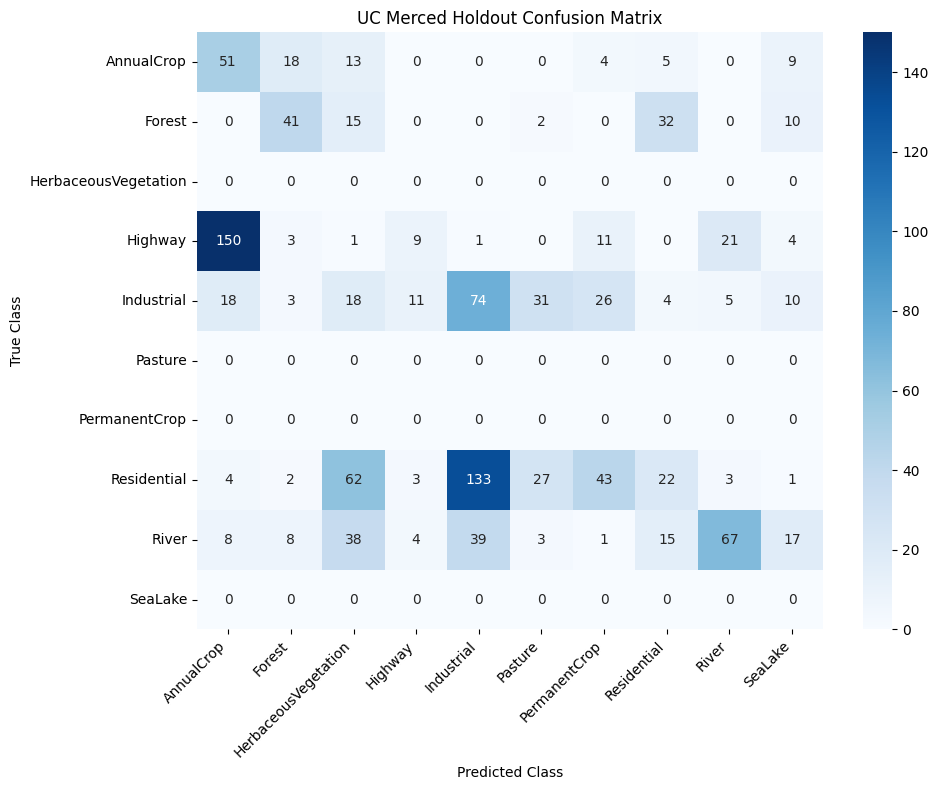

In [4]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=EUROSAT_CLASSES, yticklabels=EUROSAT_CLASSES)
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.title('UC Merced Holdout Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "uc_merced_confusion_matrix.png"), dpi=300)
plt.show()

## 4. Detailed Error Analysis (Top 5 Confident Failures)
Below we isolate the 5 errors where our model was most confident in its incorrect predictions, illustrating them with qualitative hypotheses.

Total misclassifications on UC Merced: 836 / 1100
Error 1: Image: river_30.png
  True Class: River
  Predicted Class: HerbaceousVegetation (Confidence: 0.9997)
  Hypothesis: Spatial Similarity: Class features are highly similar (e.g. River vs. HerbaceousVegetation sharing colors/textures).
----------------------------------------------------------------------


Error 2: Image: agricultural_05.png
  True Class: AnnualCrop
  Predicted Class: HerbaceousVegetation (Confidence: 0.9997)
  Hypothesis: Class Overlap: Categories share pixel characteristics (e.g. Annual Crops showing patterns identical to HerbaceousVegetation).
----------------------------------------------------------------------
Error 3: Image: denseresidential_47.png
  True Class: Residential
  Predicted Class: Industrial (Confidence: 0.9995)
  Hypothesis: Visual Ambiguity: Image has features of both classes (e.g. dense residential buildings resembling industrial compounds).
----------------------------------------------------------------------
Error 4: Image: mediumresidential_45.png
  True Class: Residential
  Predicted Class: Industrial (Confidence: 0.9993)
  Hypothesis: Scale/Resolution: Sub-features confuse the neural net (e.g. medium density housing elements misidentified as industrial).
----------------------------------------------------------------------
Error 5: Image: riv

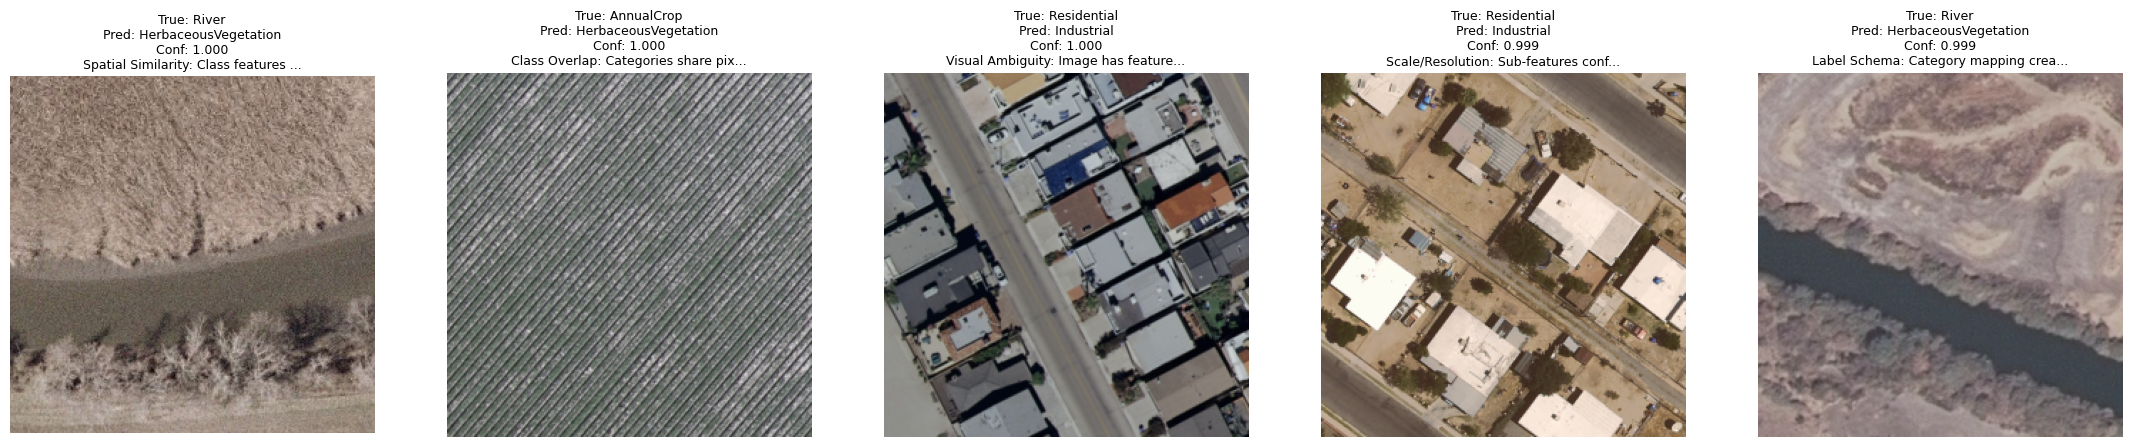

In [5]:
errors = np.where(all_preds != all_labels)[0]
print(f"Total misclassifications on UC Merced: {len(errors)} / {len(ucm_dataset)}")

if len(errors) > 0:
    error_confidences = [all_probs[idx, all_preds[idx]] for idx in errors]
    sorted_error_indices = np.argsort(error_confidences)[::-1] 
    top_5_error_indices = errors[sorted_error_indices[:5]]

    hypotheses = [
        "Spatial Similarity: Class features are highly similar (e.g. River vs. HerbaceousVegetation sharing colors/textures).",
        "Class Overlap: Categories share pixel characteristics (e.g. Annual Crops showing patterns identical to HerbaceousVegetation).",
        "Visual Ambiguity: Image has features of both classes (e.g. dense residential buildings resembling industrial compounds).",
        "Scale/Resolution: Sub-features confuse the neural net (e.g. medium density housing elements misidentified as industrial).",
        "Label Schema: Category mapping creates minor semantic gaps (e.g. rivers surrounded by green fields mapped to River vs. vegetation)."
    ]

    fig, axes = plt.subplots(1, 5, figsize=(22, 6))
    
    for idx, sample_idx in enumerate(top_5_error_indices):
        fpath = all_paths[sample_idx]
        true_lbl = EUROSAT_CLASSES[all_labels[sample_idx]]
        pred_lbl = EUROSAT_CLASSES[all_preds[sample_idx]]
        confidence = all_probs[sample_idx, all_preds[sample_idx]]

        img = plt.imread(fpath)
        axes[idx].imshow(img)
        # Use subplots_adjust rather than tight_layout to prevent cutoff
        axes[idx].set_title(f"True: {true_lbl}\nPred: {pred_lbl}\nConf: {confidence:.3f}\n{hypotheses[idx][:35]}...", fontsize=9)
        axes[idx].axis("off")
        
        print(f"Error {idx+1}: Image: {os.path.basename(fpath)}")
        print(f"  True Class: {true_lbl}")
        print(f"  Predicted Class: {pred_lbl} (Confidence: {confidence:.4f})")
        print(f"  Hypothesis: {hypotheses[idx]}")
        print("-" * 70)

    plt.subplots_adjust(top=0.80, bottom=0.05, left=0.02, right=0.98, wspace=0.2)
    plt.savefig(os.path.join(REPORTS_DIR, "top_5_errors_notebook.png"), dpi=300)
    plt.show()
else:
    print("No error to display.")